# Background/Rationale

**Project title:** *Predictive-Coding-Inspired EEG Representation Learning for Eye-Consistent Surgical Cognitive State Modeling*

**Author:** Michael A. Haidar

**Repo:** 

This project asks whether EEG can reveal cognitive structure in robot-assisted surgery more effectively when learned through predictive-coding-inspired objectives rather than a standard baseline encoder. Eye tracking captures overt attentional behavior and has already been used to build task-relevant RDMs, but it does not directly measure latent neural dynamics (Shafiei et al., 2023). EEG is a plausible complement, yet its structure is difficult to recover from noisy, high-dimensional signals.

Predictive coding provides the neurobiological rationale for this comparison: the model should separate stable expectation-like state information from mismatch-driven error signals (Whittington & Bogacz, 2019). I therefore test whether a predictive-coding EEG model aligns with eye-derived attentional structure better than a baseline CNN, and whether the prediction-error channel becomes more eye-consistent than the latent state.

## Abstract

Using 100 matched EEG and eye-tracking trials from simulated robot-assisted surgery, I compare a baseline CNN with a predictive-coding GRU trained on the same next-window prediction objective. Training produces a dissociation: the latent state becomes anti-correlated with eye-state occupancy, whereas the prediction-error channel becomes the most eye-consistent representation. Meanwhile, the latent state yields the most interpretable task-family RDM.

In [1]:
from __future__ import annotations

import re
import sys
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").exists() and (candidate / "figures").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/ and figures/.")


PROJECT_ROOT = find_project_root()
SRC = PROJECT_ROOT / "src"
FIGURES_DIR = PROJECT_ROOT / "figures"
EVAL_RESULTS_DIR = PROJECT_ROOT / "eval_results"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

required_figures = [
    "fig1_trained_vs_untrained.png",
    "fig2_per_trial_distributions.png",
    "fig3_eeg_latent_rdm.png",
    "fig4_rdm_scores.png",
]

asset_status = pd.DataFrame(
    {
        "asset": required_figures,
        "exists": [(FIGURES_DIR / name).exists() for name in required_figures],
    }
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures dir:  {FIGURES_DIR}")
print(f"Eval dir:     {EVAL_RESULTS_DIR}")
display(asset_status)


Project root: /Users/michaelhaidar/Documents/Vanderbilt/Fall_25/Surgical Robotics/Surgical_Gestures
Figures dir:  /Users/michaelhaidar/Documents/Vanderbilt/Fall_25/Surgical Robotics/Surgical_Gestures/figures
Eval dir:     /Users/michaelhaidar/Documents/Vanderbilt/Fall_25/Surgical Robotics/Surgical_Gestures/eval_results


,asset,exists
0,fig1_trained_vs_untrained.png,True
1,fig2_per_trial_distributions.png,True
2,fig3_eeg_latent_rdm.png,True
3,fig4_rdm_scores.png,True


In [2]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12


def show_figure(filename: str, figsize: tuple[int, int] = (10, 6)) -> None:
    path = FIGURES_DIR / filename
    if not path.exists():
        raise FileNotFoundError(path)

    image = mpimg.imread(path)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(filename.replace("_", " ").replace(".png", "").title())
    plt.show()


paper_results = pd.DataFrame(
    [
        {
            "Representation": "Baseline CNN",
            "Untrained_r": 0.007,
            "Trained_r": -0.085,
            "Delta_r": -0.092,
            "Positive_trials_pct": 0.0,
        },
        {
            "Representation": "PC Latent",
            "Untrained_r": 0.024,
            "Trained_r": -0.120,
            "Delta_r": -0.144,
            "Positive_trials_pct": 2.0,
        },
        {
            "Representation": "PC Prediction Error",
            "Untrained_r": -0.063,
            "Trained_r": 0.053,
            "Delta_r": 0.116,
            "Positive_trials_pct": 59.0,
        },
    ]
)

paper_results


,Representation,Untrained_r,Trained_r,Delta_r,Positive_trials_pct
0,Baseline CNN,0.007,-0.085,-0.092,0.0
1,PC Latent,0.024,-0.120,-0.144,2.0
2,PC Prediction Error,-0.063,0.053,0.116,59.0


## 1. Methods Overview

The analysis uses the public EEG and eye-gaze dataset for robot-assisted surgery performance evaluation, with synchronized EEG and eye tracking from 25 participants across 27 simulator tasks (Shafiei et al., 2023). I analyze 100 matched trials, bandpass filter EEG from 1 to 40 Hz, apply a 50 Hz notch filter, and segment the data into overlapping 1-second windows using MNE-Python (Gramfort et al., 2013).

I compare a baseline CNN with a predictive-coding GRU. The GRU produces both a latent state and a prediction-error signal, with updates summarized by $h_t = \mathrm{GRU}(\mathrm{enc}(e_t), h_{t-1})$ and $\epsilon_t = \|e_{t+1} - \hat{e}_{t+1}\|_2$. Eye structure is summarized with an HMM, alignment is measured with Spearman correlation, and task-family RDMs are computed using $d(i,j) = 1 - \rho_s(i,j)$.

## 2. Result 1: Training Produced a Dissociation Between Latent State and Prediction Error

Training pushed the two predictive-coding channels in opposite directions. After training, the latent representations became anti-correlated with eye occupancy, whereas the prediction-error channel moved positive and became the only consistently favorable representation.

This is the clearest test of the primary hypothesis and supports a predictive-coding interpretation (Whittington & Bogacz, 2019).

,Representation,Untrained_r,Trained_r,Delta_r,Positive_trials_pct
0,Baseline CNN,0.007,-0.085,-0.092,0.0
1,PC Latent,0.024,-0.120,-0.144,2.0
2,PC Prediction Error,-0.063,0.053,0.116,59.0


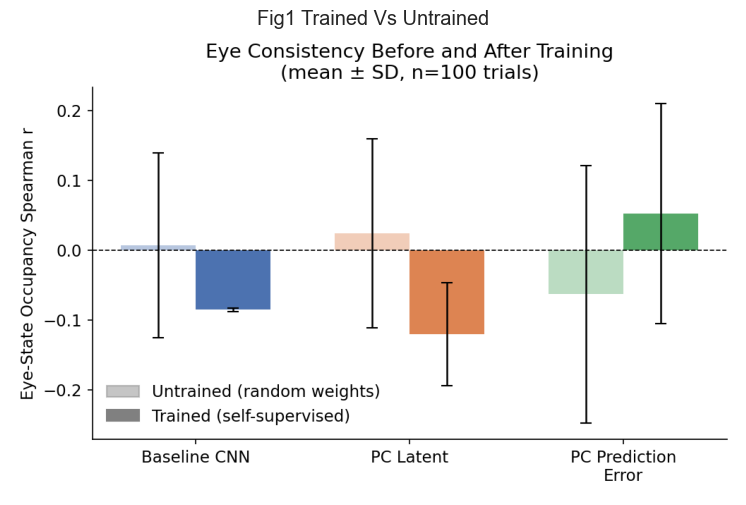

In [3]:
display(paper_results.round(3))
show_figure("fig1_trained_vs_untrained.png", figsize=(11, 6))


Figure 1 is the decisive test of the main hypothesis. Its raison d'etre is to show that training did not improve every channel uniformly; it split latent-state behavior from prediction-error behavior.

The prediction-error channel alone shifts positive, making the dissociation visually explicit.

## 3. Result 2: Per-Trial Eye Consistency Was Only Positive for the Prediction-Error Channel

The violin plot asks whether the first result reflects many trials or only a few outliers. The prediction-error channel is the only distribution centered above zero, whereas the baseline and latent-state distributions remain negative.

That makes the dissociation distributional rather than anecdotal.

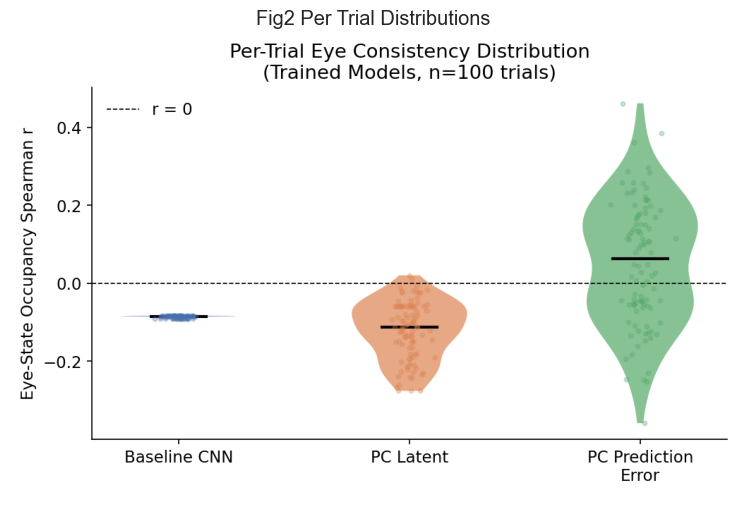

In [4]:
show_figure("fig2_per_trial_distributions.png", figsize=(11, 6))


Figure 2 is needed because averages can hide whether an effect is broad or fragile. Its raison d'etre is to show that the prediction-error advantage reflects a different distribution, not just a few extreme trials.

## 4. Result 3: The EEG Latent RDM Showed the Most Interpretable Task Geometry

The trained predictive-coding latent state produced the clearest task-family RDM, with an interpretability score of 0.81. This matters because the representation that best matches eye occupancy is not the same one that produces the richest task geometry.

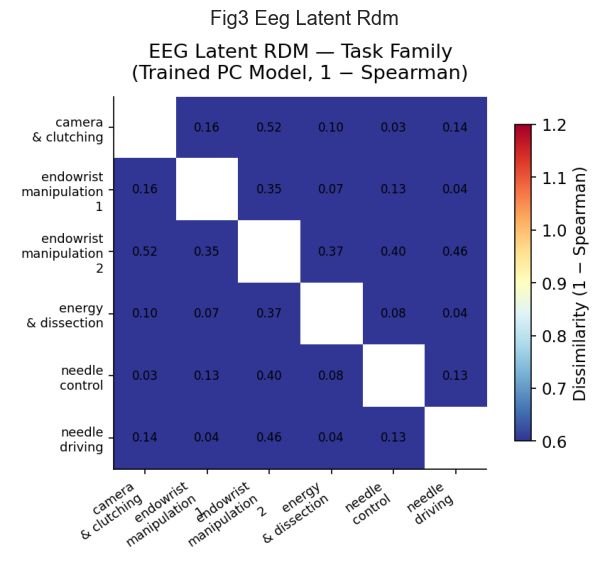

In [5]:
show_figure("fig3_eeg_latent_rdm.png", figsize=(8, 7))


Figure 3 asks whether the learned latent space contains interpretable task geometry. Its raison d'etre is to show that the latent state still matters scientifically even though it is not the most eye-consistent channel.

## 5. Result 4: The EEG Latent RDM Was the Only Strong Candidate for Downstream Transfer

Across six candidate RDMs, the EEG latent task-family RDM ranked first overall and was the only representation with clearly non-zero interpretability. The eye-only and joint RDMs were largely degenerate under the current sampling strategy, leaving the latent EEG RDM as the only strong transfer candidate.

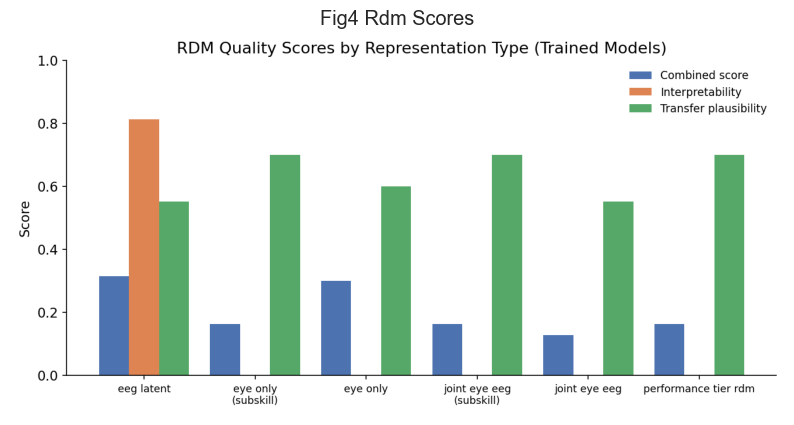

In [6]:
show_figure("fig4_rdm_scores.png", figsize=(10, 6))


Figure 4 tests whether any candidate RDM is useful beyond a single trial-level correlation. Its raison d'etre is to show that only the latent EEG RDM combines interpretability with plausible downstream relevance.

## 6. Did the Project Meet the Proposal Goals?

Yes, in the main scientific sense. Predictive-coding-inspired training produced the strongest eye alignment in the prediction-error channel, while the latent state produced the most interpretable task-family RDM.

The main unfinished pieces are stronger trained baselines, formal significance testing, and cross-dataset transfer.

## 7. Discussion and Limitations

The main theoretical contribution is the dissociation between latent state and prediction error. Under predictive coding, expectation-like state information and mismatch-driven error information should play different roles, so the stronger eye alignment of the error channel is conceptually coherent (Whittington & Bogacz, 2019). The latent state still matters because it produced the clearest task-family geometry.

The baseline CNN highlights this contrast: it became anti-correlated with eye occupancy but with little variance, suggesting a regular representation without especially rich cognitive structure. Important limitations remain: the models were small, only 100 matched trials were analyzed, stronger trained baselines were not included, some RDM analyses were incomplete or degenerate, and cross-dataset transfer was not validated.

## Appendix: Example Downstream Metrics From the Broader Repo

The table below is included only as a small appendix showing that the broader repository also contains downstream JIGSAWS task artifacts. These metrics are not the main evidence for the computational neuroscience claim.

In [7]:
def parse_eval_result(path: Path) -> dict[str, float | str | None]:
    text = path.read_text()

    def grab(pattern: str) -> float | None:
        match = re.search(pattern, text)
        return float(match.group(1)) if match else None

    return {
        "Task": path.name.replace("_test_fold_1_results.txt", ""),
        "Total_Loss": grab(r"Total Loss:\s+([0-9.]+)"),
        "Position_RMSE": grab(r"Position RMSE:\s+([0-9.]+)"),
        "Rotation_RMSE": grab(r"Rotation RMSE:\s+([0-9.]+)"),
        "Gesture_Accuracy_pct": grab(r"Gesture Classification:\n\s+Accuracy:\s+([0-9.]+)%"),
        "Skill_Accuracy_pct": grab(r"Skill Classification:\n\s+Accuracy:\s+([0-9.]+)%"),
    }


appendix_files = [
    EVAL_RESULTS_DIR / "Knot_Tying_test_fold_1_results.txt",
    EVAL_RESULTS_DIR / "Needle_Passing_test_fold_1_results.txt",
    EVAL_RESULTS_DIR / "Suturing_test_fold_1_results.txt",
]

appendix_metrics = pd.DataFrame(parse_eval_result(path) for path in appendix_files)
appendix_metrics = appendix_metrics.sort_values("Task").reset_index(drop=True)
display(appendix_metrics.round(4))


,Task,Total_Loss,Position_RMSE,Rotation_RMSE,Gesture_Accuracy_pct,Skill_Accuracy_pct
0,Knot_Tying,2.2359,0.3735,0.8436,24.32,70.27
1,Needle_Passing,1.1441,0.0366,0.7119,79.10,100.00
2,Suturing,0.6317,0.0131,1.1634,100.00,100.00


## References

Gramfort, A., Luessi, M., Larson, E., Engemann, D. A., Strohmeier, D., Brodbeck, C., Goj, R., Jas, M., Brooks, T., Parkkonen, L., et al. (2013). MEG and EEG data analysis with MNE-Python. *Frontiers in Neuroscience, 7*, 267.

Shafiei, S. B., Shadpour, S., Mohler, J., Seilanian Toussi, M., Doherty, P., & Jing, Z. (2023). *Electroencephalogram and eye-gaze datasets for robot-assisted surgery performance evaluation* (Version 1.0.0). PhysioNet. https://doi.org/10.13026/qj5m-n649

Whittington, J. C. R., & Bogacz, R. (2019). Theories of error back-propagation in the brain. *Trends in Cognitive Sciences, 23*(3), 235-250.